#### Teach Meet 5th March: LLM Output Brain-rot?

This script aims to answer the research question: "Do LLM-generated explanations reduce lexical and syntactic complexity relative to academic source texts, and could this reduce exposure to academic language?"

Overview of the Methodology:
- An academic text was taken, specifically an abstract of an academic paper: 'Examining Variable Domain Orientations in Antigen Receptors Gives Insight into TCR-Like Antibody Design', from the journal 'Computational Biology'

- Three prompts were then asked: 
    a) Can you explain this to me at a postgraduate student level?
    b) Please rewrite this in simpler language
    c) Explain this clearly but please retain academic language

- This was then repeated with a GCSE history text, to compare the lexicon of different levels, to understand if there was an increased impact on differing academic levels
    

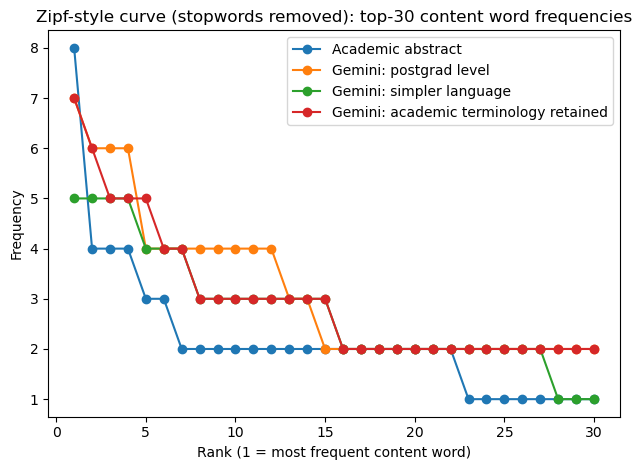

                                       Word count  Sentence count  \
Text                                                                
Academic abstract                             228              13   
Gemini: postgrad level                        427              12   
Gemini: simpler language                      330               5   
Gemini: academic terminology retained         358               7   

                                       Mean sentence length  \
Text                                                          
Academic abstract                                    17.538   
Gemini: postgrad level                               35.583   
Gemini: simpler language                             66.000   
Gemini: academic terminology retained                51.143   

                                       Lexical density (non-stopwords)  \
Text                                                                     
Academic abstract                                         

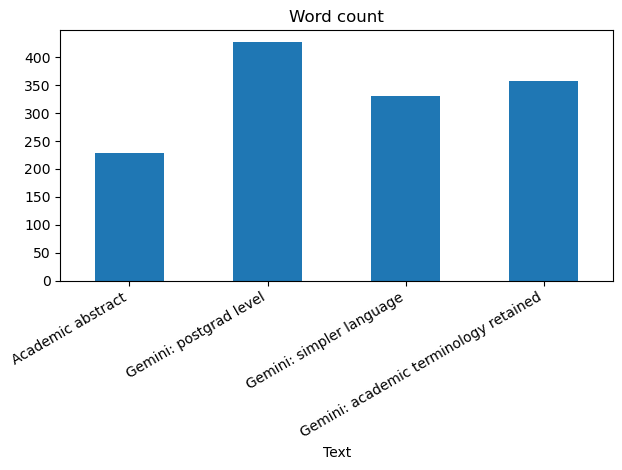

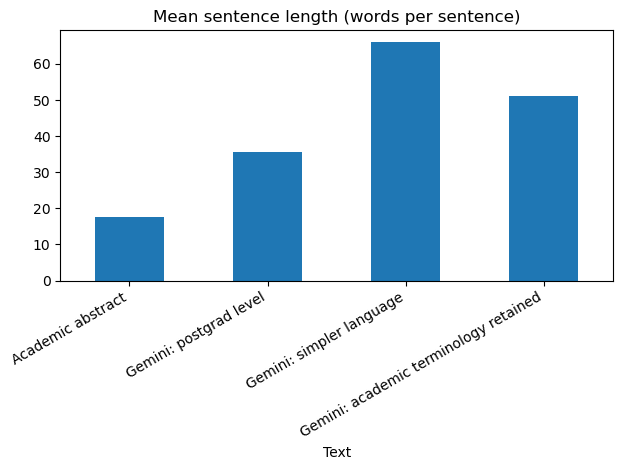

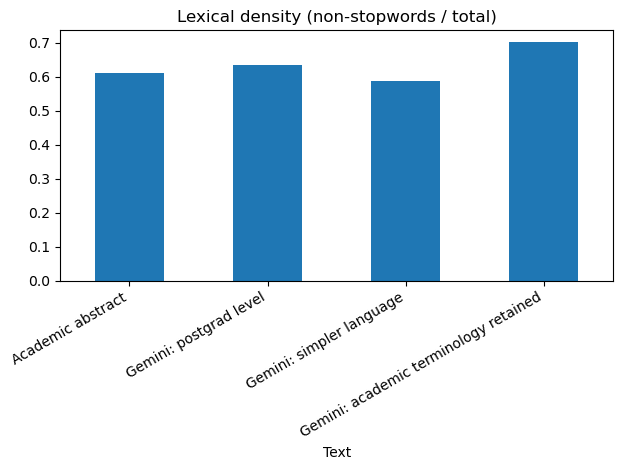

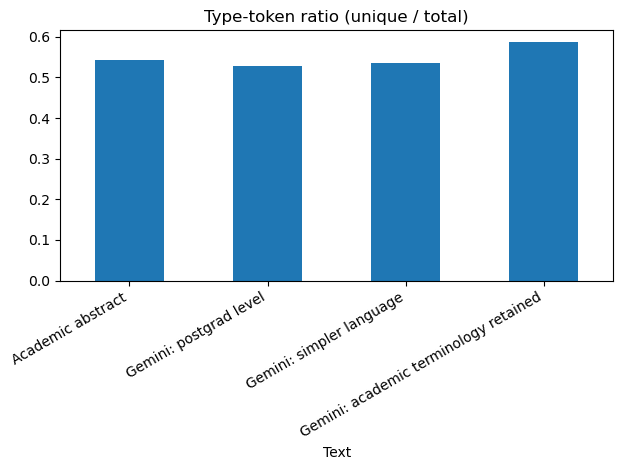

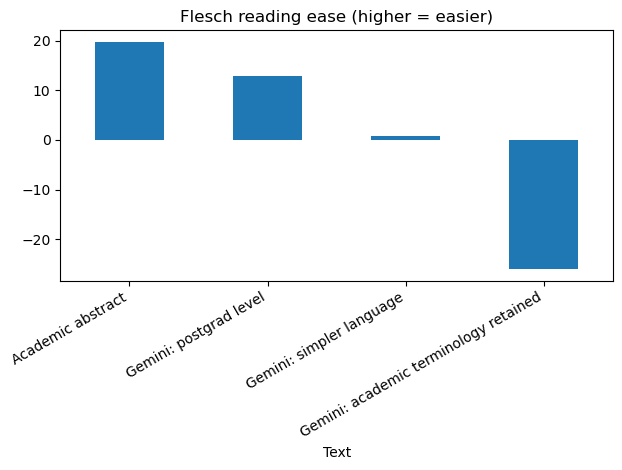

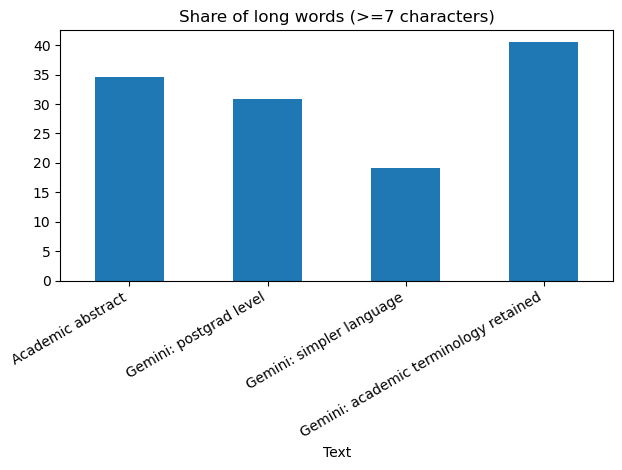

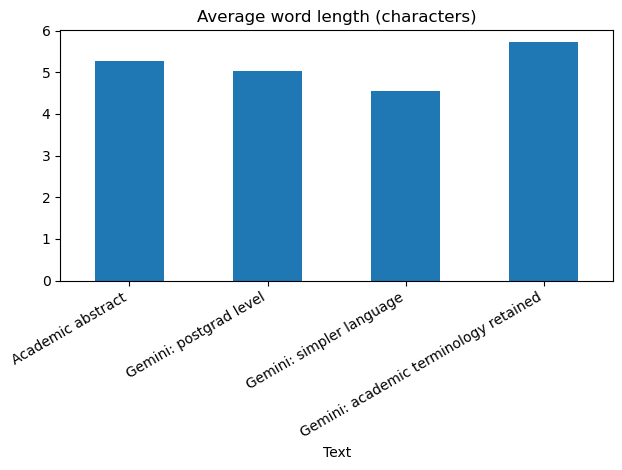

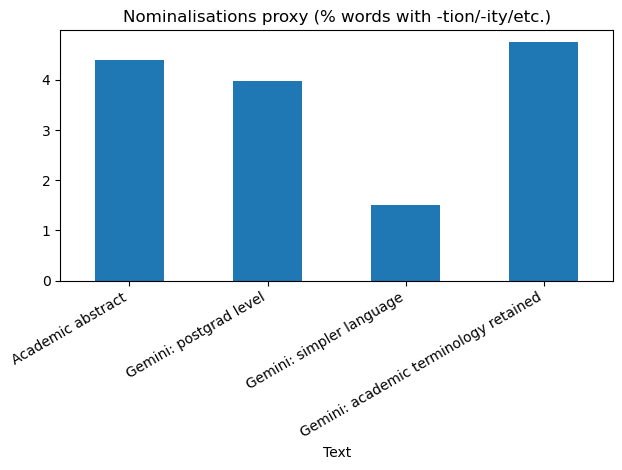

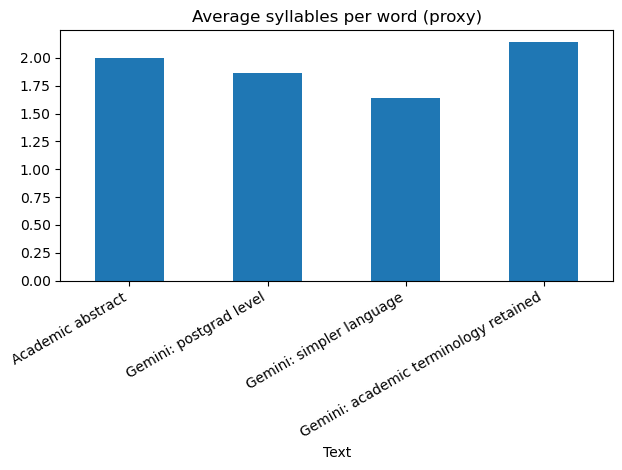

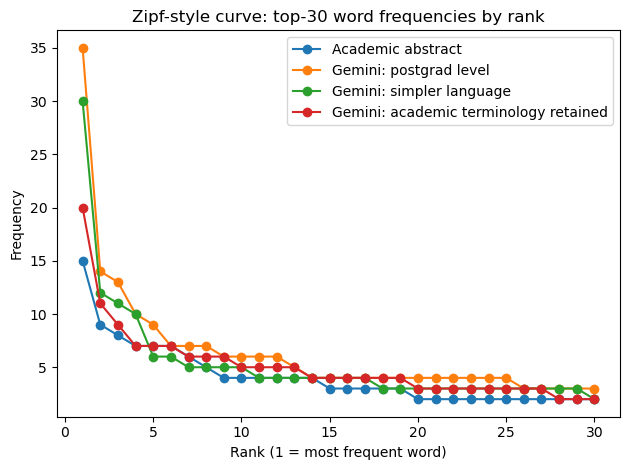

In [2]:
# imports

import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Paste your texts EXACTLY as you want analysed (including headings if you want them counted)
TEXTS = {
    "Academic abstract": r"""
The variable domains of antibodies and T-Cell receptors (TCRs) share similar structures. Both molecules act as sensors for the immune system but recognise their respective antigens in different ways. Antibodies bind to a diverse set of antigenic shapes whilst TCRs only recognise linear peptides presented by a major histocompatibility complex (MHC). The antigen specificity and affinity of both receptors is determined primarily by the sequence and structure of their complementarity determining regions (CDRs). In antibodies the binding site is also known to be affected by the relative orientation of the variable domains, VH and VL. Here, the corresponding property for TCRs, the Vβ-Vα orientation, is investigated and compared with that of antibodies. We find that TCR and antibody orientations are distinct. General antibody orientations are found to be incompatible with binding to the MHC in a canonical TCR-like mode. Finally, factors that cause the orientation of TCRs and antibodies to be different are investigated. Packing of the long Vα CDR3 in the domain-domain interface is found to be influential. In antibodies, a similar packing affect can be achieved using a bulky residue at IMGT position 50 on the VH domain. Along with IMGT VH 50, other positions are identified that may help to promote a TCR-like orientation in antibodies. These positions should provide useful considerations in the engineering of therapeutic TCR-like antibodies.
""",
    "Gemini: postgrad level": r"""
This abstract touches on a sophisticated area of structural immunology: the quaternary geometry of antigen receptors. While we often focus on the primary sequences of CDR loops, this research highlights how the "twist" and "tilt" between the two variable domains—the $\text{V}_{\text{H}}\text{-}\text{V}_{\text{L}}$ or $\text{V}_{\alpha}\text{-}\text{V}_{\beta}$ interface—dictates binding capacity and biological function.Here is a breakdown of the core concepts for a postgraduate level:1. The Geometry of Recognition: Orientation MattersIn both antibodies (Abs) and T-cell receptors (TCRs), the binding site is a paratope formed by the juxtaposition of two domains. However, they aren't static blocks. The relative orientation of these domains can be described using specific coordinates (often tilt, twist, and shift angles).Antibodies: Evolved for high-affinity "lock and key" fits against diverse, 3D epitopes (proteins, lipids, carbohydrates). Their orientation is broad and varied to accommodate these shapes.TCRs: Evolved for a highly constrained task—recognizing a linear peptide nested within the groove of an MHC molecule.The study finds that TCRs occupy a specific "orientational niche" that is distinct from antibodies. If an antibody were to adopt its typical orientation while trying to dock onto an MHC, it would likely result in steric clashes or a failure to align its CDR loops with the peptide-MHC (pMHC) surface.2. The Role of the CDR3 Loop as an Interface AnchorIn TCRs, the $\text{V}_{\alpha}$ CDR3 loop is typically longer and plays a dual role. Not only does it contact the peptide, but it also "packs" into the interface between the $\text{V}_{\alpha}$ and $\text{V}_{\beta}$ domains.This internal packing acts as a physical spacer or wedge, forcing the TCR into its canonical orientation. In most antibodies, the $\text{V}_{\text{H}}\text{-}\text{V}_{\text{L}}$ interface is packed differently, leading to the distinct geometric divergence noted in the text.3. Engineering "TCR-like" AntibodiesThere is significant therapeutic interest in TCR-like antibodies (TCRmAbs)—antibodies that can target intracellular proteins by binding to the peptide-MHC complex. These are "the best of both worlds": the targeting specificity of a TCR with the stability and recruitment power of an antibody.The abstract identifies specific "knobs" that engineers can turn to make an antibody "act" like a TCR geometrically:IMGT Position 50 (VH): By placing a bulky residue here, engineers can mimic the packing effect of the TCR $\text{V}_{\alpha}$ CDR3.Interface Re-engineering: By modifying specific residues at the VH-VL interface, you can shift the equilibrium of the antibody’s orientation toward the "canonical TCR-like mode," potentially increasing the affinity for pMHC targets.
""",
    "Gemini: simpler language": r"""
Think of antibodies and T-cell receptors (TCRs) as the "scouts" of the immune system. While they look physically similar, they have very different jobs: antibodies grab onto almost any shape (like a whole bacteria or virus), while TCRs are much pickier—they only recognize small protein fragments (peptides) held up by a specific "tray" called the MHC.This study looks at how the physical "pose" of these sensors affects their ability to do their jobs.The "Twist" of the SensorBoth of these sensors are made of two main parts that sit next to each other. The way these two parts are angled or "twisted" relative to one another changes the shape of the docking site.The Problem: The researchers found that antibodies and TCRs naturally sit at very different angles. In fact, the typical "pose" of an antibody is actually incompatible with the way a TCR needs to dock onto an MHC "tray."The Cause: They discovered that TCRs have a long internal loop (called the $\text{V}_{\alpha}$ CDR3) that acts like a wedge, forcing the two halves of the sensor into a specific orientation. Antibodies usually lack this "wedge," so they sit differently.Why This Matters for MedicineScientists are trying to create "TCR-like antibodies"—medications that have the strength of an antibody but the precision of a TCR to find hidden disease markers (like those inside cancer cells).The study found a shortcut for engineers:The "Wedge" Trick: By placing a large, bulky amino acid at a specific spot in the antibody (called IMGT position 50), they can mimic that TCR "wedge" effect.The Result: This forces the antibody to change its pose to look more like a TCR, making it much better at docking onto the MHC tray.In short: If you want an antibody to do a TCR's job, you can't just change the "fingertips" (the binding loops); you have to change the "wrist angle" (the domain orientation) so it can reach the target correctly.
""",
    "Gemini: academic terminology retained": r"""
This research investigates the quaternary structure of immune receptors, specifically focusing on how the relative "tilt" or orientation between two variable domains dictates their ability to recognize targets. While antibodies and T-cell receptors (TCRs) share a common immunoglobulin fold, their geometric configurations are specialized for distinct biological roles.Structural Divergence in Antigen RecognitionThe primary functional difference between these molecules lies in their ligand topology:Antibodies ($\text{V}_{\text{H}}/\text{V}_{\text{L}}$): Recognize diverse, three-dimensional epitopes. Their variable domain orientation is highly flexible, allowing them to adapt to various surface shapes.TCRs ($\text{V}_{\alpha}/\text{V}_{\beta}$): Recognize a highly specific, relatively flat surface consisting of a linear peptide embedded in a Major Histocompatibility Complex (MHC).The researchers discovered that TCRs occupy a unique "orientational space" that is distinct from antibodies. Crucially, the standard geometric orientation of an antibody is physically incompatible with the "canonical" docking mode required to bind an MHC molecule.The Role of Domain-Domain Interface PackingThe study identifies the $\text{V}_{\alpha}$ CDR3 loop as a primary structural driver in TCRs. In many TCRs, this loop is long and "packs" into the interface between the two variable domains. This packing acts as a physical spacer, locking the TCR into the specific orientation necessary for pMHC (peptide-MHC) recognition.Implications for Immunotherapy EngineeringThe findings are particularly relevant for the development of TCR-like antibodies (antibodies engineered to target intracellular peptides presented on MHC). To make an antibody "act" like a TCR, simply grafting the binding loops (CDRs) is insufficient; the underlying "chassis" or domain orientation must also be corrected.Key engineering insights include:IMGT Position 50 ($\text{V}_{\text{H}}$): By introducing a "bulky" amino acid at this specific position, engineers can mimic the packing effect of the TCR's $\text{V}_{\alpha}$ CDR3.Orientation Steering: Manipulating position 50, along with other identified residues, can force an antibody to adopt a "TCR-like" pose, significantly improving its potential to bind MHC targets with high affinity.Summary for Engineering: Success in creating therapeutic TCR-like antibodies requires a "whole-module" approach where the VH-VL orientation is shifted to match the TCR's geometry, ensuring the paratope is correctly aligned with the pMHC surface.
""",
}

# ----------------------------
# Basic preprocessing utilities
# ----------------------------

def normalise(text: str) -> str:
    # Remove common LaTeX artifacts (optional; keep if you want)
    # This removes \text{...} but keeps the inside.
    text = re.sub(r"\\text\{([^}]*)\}", r"\1", text)
    # Remove remaining backslash commands like \alpha, \beta etc. (keeps the token name)
    text = re.sub(r"\\([A-Za-z]+)", r"\1", text)
    # Remove stray braces
    text = text.replace("{", " ").replace("}", " ")
    return text

def word_tokens(text: str):
    text = normalise(text)
    # words + hyphenated words; keeps things like "T-cell" as two tokens unless you prefer otherwise
    return re.findall(r"\b[\w']+\b", text.lower())

def sentence_split(text: str):
    text = normalise(text).strip()
    # a simple sentence splitter; good enough for this use case
    sents = re.split(r"(?<=[.!?])\s+", text)
    return [s for s in sents if s and re.search(r"[A-Za-z0-9]", s)]

# A small stopword list (you can expand this; it affects lexical density)
STOPWORDS = set("""
the a an and or but if while as of in on at for to from by with into onto over under
is are was were be been being this that these those it its they them their you your
we our i me my he him his she her hers who whom which what when where why how
can could may might should would will shall do does did doing done
not no nor very more most less least just only also than then
""".split())

VOWEL_GROUP = re.compile(r"[aeiouy]+", re.I)

def syllable_count(word: str) -> int:
    # crude syllable estimate; consistent across texts, which is what you want for comparison
    groups = VOWEL_GROUP.findall(word.lower())
    return max(1, len(groups))

def mean_sentence_length(words, sentences) -> float:
    return len(words) / max(1, len(sentences))

def type_token_ratio(words) -> float:
    return len(set(words)) / max(1, len(words))

def lexical_density(words) -> float:
    # proxy: non-stopwords / total words
    content = [w for w in words if w not in STOPWORDS]
    return len(content) / max(1, len(words))

def avg_word_length(words) -> float:
    return np.mean([len(w) for w in words]) if words else 0.0

def pct_long_words(words, n=7) -> float:
    return 100.0 * sum(1 for w in words if len(w) >= n) / max(1, len(words))

def avg_syllables_per_word(words) -> float:
    return np.mean([syllable_count(w) for w in words]) if words else 0.0

def flesch_reading_ease(words, sentences) -> float:
    # Flesch Reading Ease = 206.835 − 1.015*(words/sentences) − 84.6*(syllables/words)
    syllables = sum(syllable_count(w) for w in words)
    w = max(1, len(words))
    s = max(1, len(sentences))
    return 206.835 - 1.015*(w/s) - 84.6*(syllables/w)

def nominalisation_rate(words) -> float:
    # crude proxy: proportion of words ending with common nominalisation suffixes
    suffixes = ("tion", "sion", "ment", "ness", "ity", "ance", "ence", "ship", "ism", "ality")
    return 100.0 * sum(1 for w in words if w.endswith(suffixes)) / max(1, len(words))


def content_words(text, min_len=3):
    words = word_tokens(text)
    return [
        w for w in words
        if w not in STOPWORDS and len(w) >= min_len
    ]


from collections import Counter
import matplotlib.pyplot as plt

def zipf_curve(words, top_n=30):
    counts = Counter(words)
    ranked = sorted(counts.values(), reverse=True)
    return ranked[:top_n]

plt.figure()

for label, raw in TEXTS.items():
    words = content_words(raw, min_len=3)
    ranked = zipf_curve(words, top_n=30)
    plt.plot(range(1, len(ranked)+1), ranked, marker="o", label=label)

plt.title("Zipf-style curve (stopwords removed): top-30 content word frequencies")
plt.xlabel("Rank (1 = most frequent content word)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------
# 2) Compute metrics
# ----------------------------

rows = []
token_cache = {}

for label, raw in TEXTS.items():
    words = word_tokens(raw)
    sents = sentence_split(raw)
    token_cache[label] = (words, sents)

    rows.append({
        "Text": label,
        "Word count": len(words),
        "Sentence count": len(sents),
        "Mean sentence length": mean_sentence_length(words, sents),
        "Lexical density (non-stopwords)": lexical_density(words),
        "Type-token ratio": type_token_ratio(words),
        "Avg word length": avg_word_length(words),
        "% long words (>=7 chars)": pct_long_words(words, 7),
        "Avg syllables/word": avg_syllables_per_word(words),
        "Flesch reading ease": flesch_reading_ease(words, sents),
        "Nominalisations (%)": nominalisation_rate(words),
    })

df = pd.DataFrame(rows).set_index("Text")
pd.set_option("display.max_columns", None)
print(df.round(3))

# ----------------------------
# 3) Sanity checks you can eyeball
# ----------------------------

print("\n--- Quick sanity checks (first 30 tokens) ---")
for label, (words, sents) in token_cache.items():
    print(f"\n{label}:")
    print("First 30 word tokens:", words[:30])
    print("First 2 sentences:", sents[:2])

# ----------------------------
# 4) Charts (you can easily get to 8–10)
# ----------------------------

def bar(metric_col, title):
    plt.figure()
    df[metric_col].plot(kind="bar")
    plt.title(title)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

bar("Word count", "Word count")
bar("Mean sentence length", "Mean sentence length (words per sentence)")
bar("Lexical density (non-stopwords)", "Lexical density (non-stopwords / total)")
bar("Type-token ratio", "Type-token ratio (unique / total)")
bar("Flesch reading ease", "Flesch reading ease (higher = easier)")
bar("% long words (>=7 chars)", "Share of long words (>=7 characters)")
bar("Avg word length", "Average word length (characters)")
bar("Nominalisations (%)", "Nominalisations proxy (% words with -tion/-ity/etc.)")
bar("Avg syllables/word", "Average syllables per word (proxy)")

# Zipf curves (word frequency rank plot)
plt.figure()
for label, (words, _) in token_cache.items():
    ranked = zipf_curve(words, top_n=30)
    plt.plot(range(1, len(ranked)+1), ranked, marker="o", label=label)
plt.title("Zipf-style curve: top-30 word frequencies by rank")
plt.xlabel("Rank (1 = most frequent word)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()



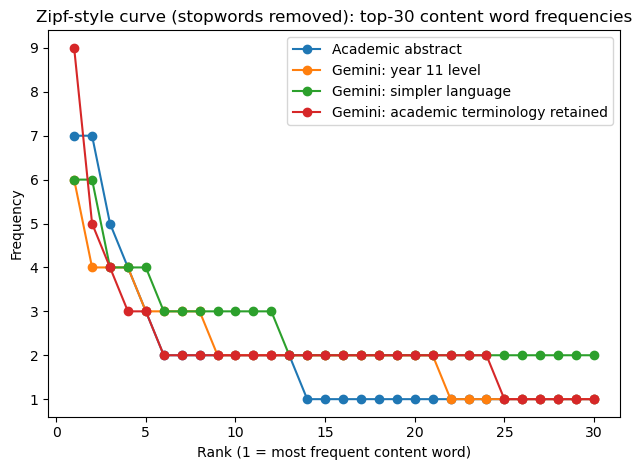

                                       Word count  Sentence count  \
Text                                                                
Academic abstract                             238              14   
Gemini: year 11 level                         322              19   
Gemini: simpler language                      332              20   
Gemini: academic terminology retained         390              25   

                                       Mean sentence length  \
Text                                                          
Academic abstract                                    17.000   
Gemini: year 11 level                                16.947   
Gemini: simpler language                             16.600   
Gemini: academic terminology retained                15.600   

                                       Lexical density (non-stopwords)  \
Text                                                                     
Academic abstract                                         

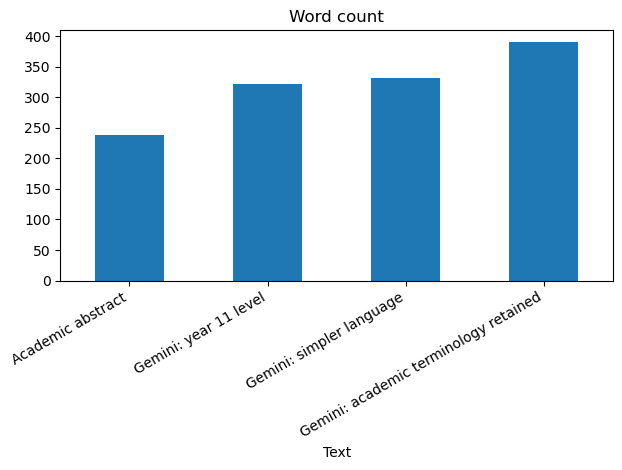

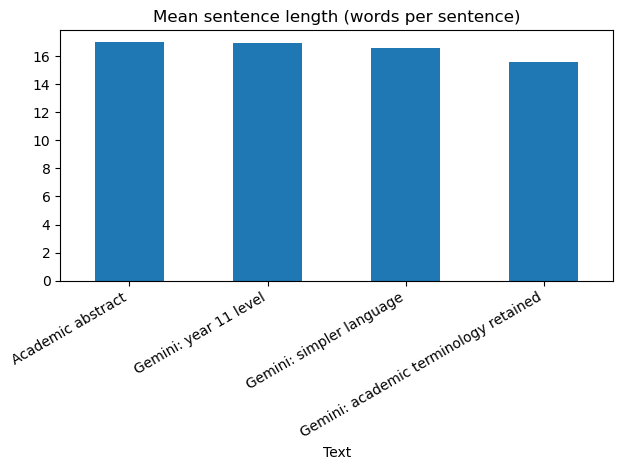

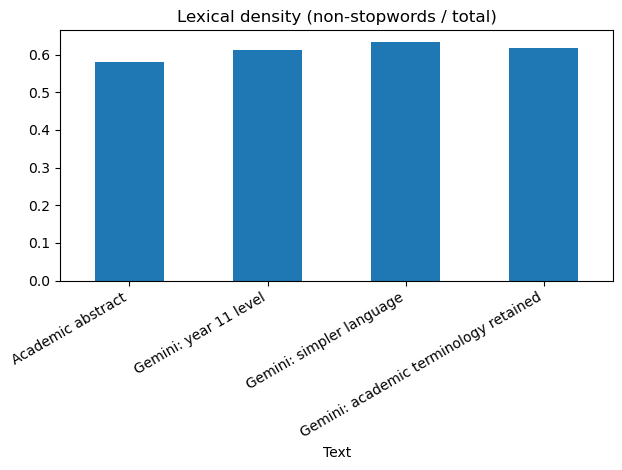

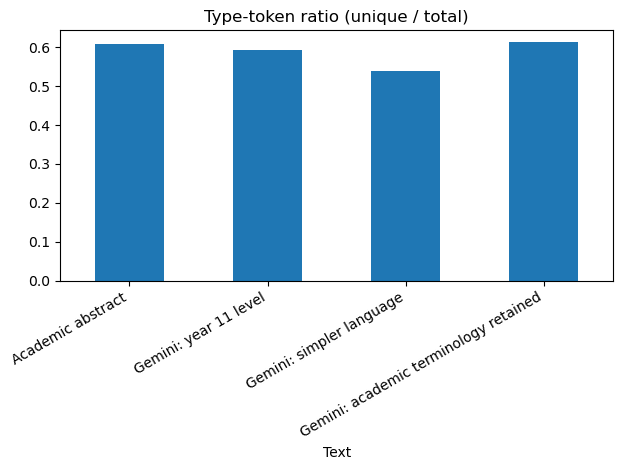

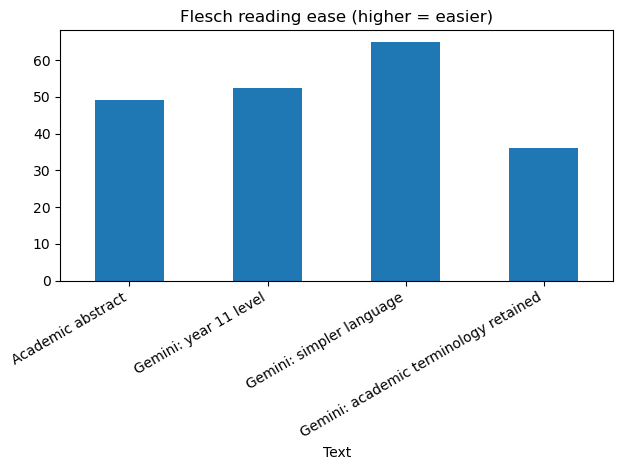

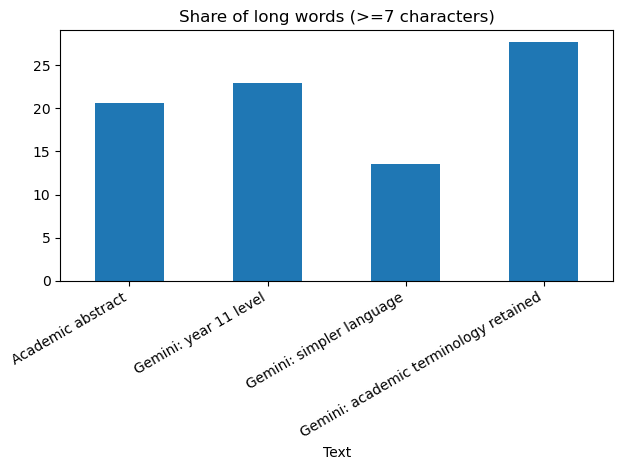

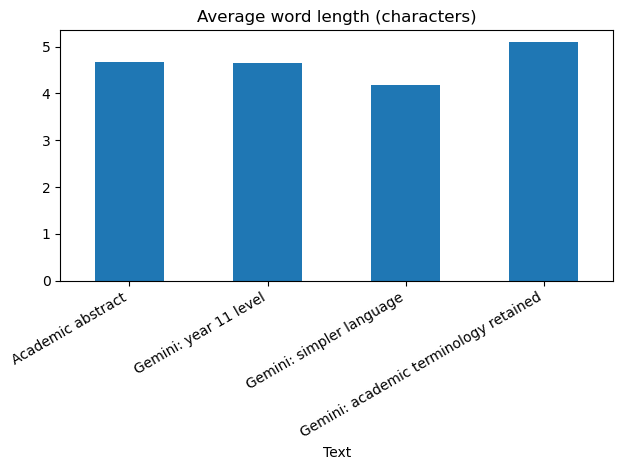

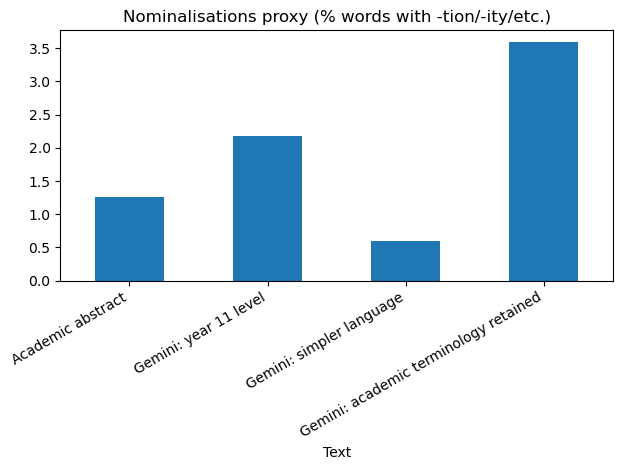

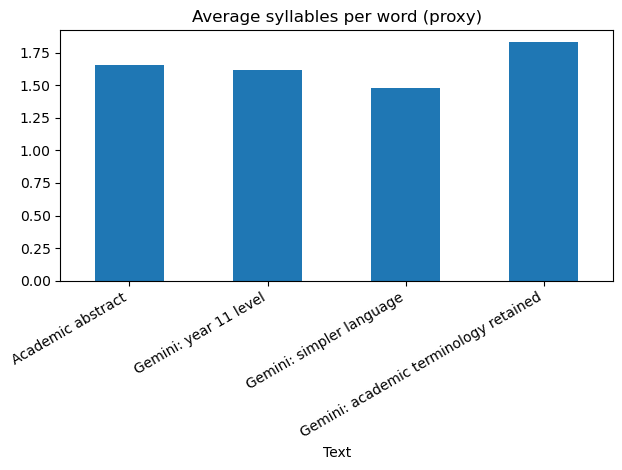

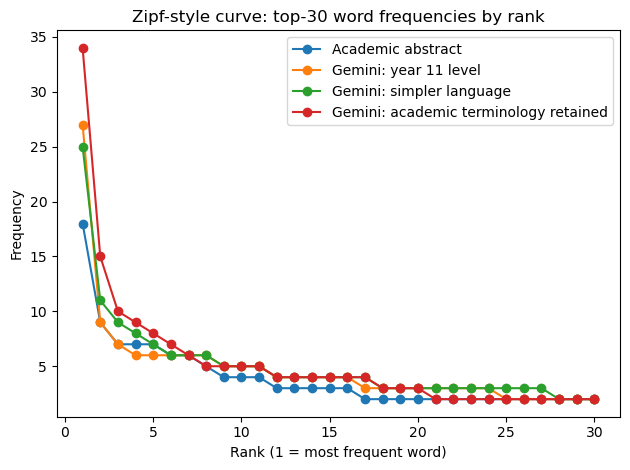

In [3]:
#### GCSE History Text

# imports

import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Paste your texts EXACTLY as you want analysed (including headings if you want them counted)
TEXTS = {
    "Academic abstract": r"""
Between 1918 and 1933 Adolf Hitler rose from being an obscure and demoralised member of the defeated German army to become the all-powerful Führer, DICTATOR of Germany, with almost unlimited power and an overwhelming ambition to make Germany great once again. His is an astonishing story which you can read about in detail in Chapter 9. Here you will be concentrating on just one intriguing and controversial question: how far was Hitler responsible for the outbreak of the Second World War? 
Hitler’s plans
Hitler was never secretive about his plans for Germany. As early as 1925 he had laid out in his book MEIN KAMPF what he would do if the Nazis ever achieved power in Germany. Abolish the Treaty of Versailles! Like many Germans, Hitler believed that the TREATY OF VERSAILLES was unjust. He hated the Treaty and called the German leaders who had signed it THE NOVEMBER CRIMINALS. The Treaty was a constant reminder to Germans of their defeat in the First World War and their humiliation by the Allies. Hitler promised that if he became leader of Germany he would reverse it (see Source 1). By the time he came to power in Germany, some of the terms had already been changed. For example, Germany had stopped making REPARATIONS payments altogether. However, most points were still in place. The table on page 59 shows the terms of the Treaty that most angered Hitler.
""",
    "Gemini: year 11 level": r"""
This text is a classic starting point for the History GCSE (specifically the "Conflict and Tension" or "International Relations" modules). It’s setting the stage for one of the biggest debates you’ll face in your exams: Was WWII inevitable because of Hitler’s specific ideology, or was it caused by a mix of long-term factors?

Here is a breakdown of what you need to know for your revision:

1. The "Road to War" Narrative
The text introduces Hitler not just as a leader, but as a man with a long-term vision. For your exam, you need to know that Hitler’s foreign policy wasn’t random; it was a checklist he’d been shouting about since 1925.

Key Term: Mein Kampf (My Struggle)
While in prison in 1924, Hitler wrote his manifesto. This is your "evidence" for his intent. He outlined three main goals:

Abolish Versailles: Reclaim lost land and rebuild the military.

Lebensraum (Living Space): Expand Germany into Eastern Europe and Russia.

Grossdeutschland (Greater Germany): Unite all German-speaking people into one Reich (e.g., Austria and the Sudetenland).

2. The Treaty of Versailles (The "Stab in the Back")
The text mentions the "November Criminals." This is a vital term for your "Depth Study" on Germany.

The Myth: Hitler pushed the idea that the German army hadn't actually lost WWI on the battlefield but was "stabbed in the back" by politicians at home (Socialists and Jewish people) who signed the Armistice in November 1918.

The Humiliation: The Treaty wasn't just about money; it was about Article 231 (War Guilt). Germans felt their national honor had been destroyed.

3. Context: What had already changed?
The text makes a smart point: by 1933, the Treaty was already "leaking."

Reparations: Due to the Great Depression and the Young Plan, Germany had basically stopped paying.

The Challenge: Hitler’s job wasn't to start the resistance to Versailles, but to accelerate it aggressively.
""",
    "Gemini: simpler language": r"""
1. Hitler’s "To-Do List"
Imagine a guy who loses a game, gets really angry, and spends 10 years writing a book about exactly how he’s going to win the rematch. That’s Hitler and his book, "Mein Kampf."

By the time he became leader (the Führer) in 1933, he had a clear "To-Do List" to make Germany powerful again:

Step 1: Rip up the Treaty of Versailles (the rules made after WWI).

Step 2: Get back all the land Germany lost.

Step 3: Bring all German-speaking people together into one big country.

Step 4: Expand into Eastern Europe for "Living Space" (Lebensraum).

2. The "Blame Game"
Hitler used a very specific trick to get people on his side. He told Germans they didn't actually lose World War I on the battlefield. Instead, he claimed they were betrayed by the politicians who signed the peace treaty.

He called these politicians the "November Criminals."

Why it worked: It’s easier to follow a leader who says "You didn't fail, you were cheated" than one who says "You lost fair and square."

3. Why the Treaty of Versailles mattered
The Treaty of Versailles was the "peace treaty" that ended WWI, but for Germans, it felt like a bullying contract. It forced them to:

Pay massive amounts of money (Reparations).

Have a tiny army (only 100,000 men).

Take 100% of the blame for the war.

The text you uploaded explains that by 1933, Germany had already stopped paying the money. Hitler’s goal was to finish the job and break all the other rules, too.

The Big GCSE Question:
Was it all Hitler’s fault? The text asks: "How far was Hitler responsible?" * One side: Yes, he literally wrote a book saying he would start a war, and then he did.

The other side: The Treaty was so harsh and the other countries (like Britain and France) were so weak that any strong German leader might have started a war.
""",
    "Gemini: academic terminology retained": r"""
Understood. Let’s elevate the analysis to the level required for a Grade 8 or 9 response. In GCSE History, you aren't just reciting facts; you are evaluating historiography (how historians interpret the past).

The text you provided centers on the Intentionalist vs. Structuralist debate regarding the origins of the Second World War.

1. The Intentionalist Argument: Hitler’s "Master Plan"
The text highlights Mein Kampf (1925) as a blueprint for war. Historians like Andreas Hillgruber argue that Hitler had a Stufenplan (a stage-by-stage plan).

Ideological Consistency: Hitler’s aims remained static from the 1920s through the 1940s. These were not mere reactions to events but a premeditated "To-Do List."

The Overthrow of the "Diktat": Hitler viewed the Treaty of Versailles not as a legal document, but as a "Diktat" (a dictated peace). By labeling the Weimar politicians as the "November Criminals," he delegitimized the democratic state and framed his future aggression as a moral "restoration" of German honor.

2. The Structuralist/Functionalist Counter-Argument
While the text focuses heavily on Hitler’s agency, a top-tier GCSE answer must acknowledge that Hitler didn't operate in a vacuum. This is often called the Functionalist view (associated with historians like A.J.P. Taylor).

Opportunism vs. Planning: Taylor famously argued that Hitler was an opportunist who "buzzed like a bee" from one crisis to the next, taking advantage of the mistakes of other leaders (like the failure of Appeasement).

Systemic Pressures: The text mentions that reparations had already stopped by 1933. This suggests that the "Post-War Settlement" was already collapsing under its own weight. Hitler was arguably "pushing on an open door."

3. Key Concepts for High-Level Evaluation
To demonstrate "complex analysis" (AO2) in your exam, you should use these terms when discussing this text:

Revisionism: Hitler was a "Revisionist" leader—meaning his primary goal was to revise (change) the terms of the 1919 settlement.

Lebensraum & Autarky: His plans weren't just about land; they were about Autarky (economic self-sufficiency). To avoid being defeated by a naval blockade again (as in WWI), he needed the resources of the East.

The Dolchstoßlegende (Stab-in-the-back Myth): This is the academic term for the "November Criminals" narrative. It served as the foundation for his domestic popularity, allowing him to bypass traditional diplomacy in favor of aggressive rearmament.
""",
}

# ----------------------------
# Basic preprocessing utilities
# ----------------------------

def normalise(text: str) -> str:
    # Remove common LaTeX artifacts (optional; keep if you want)
    # This removes \text{...} but keeps the inside.
    text = re.sub(r"\\text\{([^}]*)\}", r"\1", text)
    # Remove remaining backslash commands like \alpha, \beta etc. (keeps the token name)
    text = re.sub(r"\\([A-Za-z]+)", r"\1", text)
    # Remove stray braces
    text = text.replace("{", " ").replace("}", " ")
    return text

def word_tokens(text: str):
    text = normalise(text)
    # words + hyphenated words; keeps things like "T-cell" as two tokens unless you prefer otherwise
    return re.findall(r"\b[\w']+\b", text.lower())

def sentence_split(text: str):
    text = normalise(text).strip()
    # a simple sentence splitter; good enough for this use case
    sents = re.split(r"(?<=[.!?])\s+", text)
    return [s for s in sents if s and re.search(r"[A-Za-z0-9]", s)]

# A small stopword list (you can expand this; it affects lexical density)
STOPWORDS = set("""
the a an and or but if while as of in on at for to from by with into onto over under
is are was were be been being this that these those it its they them their you your
we our i me my he him his she her hers who whom which what when where why how
can could may might should would will shall do does did doing done
not no nor very more most less least just only also than then
""".split())

VOWEL_GROUP = re.compile(r"[aeiouy]+", re.I)

def syllable_count(word: str) -> int:
    # crude syllable estimate; consistent across texts, which is what you want for comparison
    groups = VOWEL_GROUP.findall(word.lower())
    return max(1, len(groups))

def mean_sentence_length(words, sentences) -> float:
    return len(words) / max(1, len(sentences))

def type_token_ratio(words) -> float:
    return len(set(words)) / max(1, len(words))

def lexical_density(words) -> float:
    # proxy: non-stopwords / total words
    content = [w for w in words if w not in STOPWORDS]
    return len(content) / max(1, len(words))

def avg_word_length(words) -> float:
    return np.mean([len(w) for w in words]) if words else 0.0

def pct_long_words(words, n=7) -> float:
    return 100.0 * sum(1 for w in words if len(w) >= n) / max(1, len(words))

def avg_syllables_per_word(words) -> float:
    return np.mean([syllable_count(w) for w in words]) if words else 0.0

def flesch_reading_ease(words, sentences) -> float:
    # Flesch Reading Ease = 206.835 − 1.015*(words/sentences) − 84.6*(syllables/words)
    syllables = sum(syllable_count(w) for w in words)
    w = max(1, len(words))
    s = max(1, len(sentences))
    return 206.835 - 1.015*(w/s) - 84.6*(syllables/w)

def nominalisation_rate(words) -> float:
    # crude proxy: proportion of words ending with common nominalisation suffixes
    suffixes = ("tion", "sion", "ment", "ness", "ity", "ance", "ence", "ship", "ism", "ality")
    return 100.0 * sum(1 for w in words if w.endswith(suffixes)) / max(1, len(words))


def content_words(text, min_len=3):
    words = word_tokens(text)
    return [
        w for w in words
        if w not in STOPWORDS and len(w) >= min_len
    ]


from collections import Counter
import matplotlib.pyplot as plt

def zipf_curve(words, top_n=30):
    counts = Counter(words)
    ranked = sorted(counts.values(), reverse=True)
    return ranked[:top_n]

plt.figure()

for label, raw in TEXTS.items():
    words = content_words(raw, min_len=3)
    ranked = zipf_curve(words, top_n=30)
    plt.plot(range(1, len(ranked)+1), ranked, marker="o", label=label)

plt.title("Zipf-style curve (stopwords removed): top-30 content word frequencies")
plt.xlabel("Rank (1 = most frequent content word)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------
# 2) Compute metrics
# ----------------------------

rows = []
token_cache = {}

for label, raw in TEXTS.items():
    words = word_tokens(raw)
    sents = sentence_split(raw)
    token_cache[label] = (words, sents)

    rows.append({
        "Text": label,
        "Word count": len(words),
        "Sentence count": len(sents),
        "Mean sentence length": mean_sentence_length(words, sents),
        "Lexical density (non-stopwords)": lexical_density(words),
        "Type-token ratio": type_token_ratio(words),
        "Avg word length": avg_word_length(words),
        "% long words (>=7 chars)": pct_long_words(words, 7),
        "Avg syllables/word": avg_syllables_per_word(words),
        "Flesch reading ease": flesch_reading_ease(words, sents),
        "Nominalisations (%)": nominalisation_rate(words),
    })

df = pd.DataFrame(rows).set_index("Text")
pd.set_option("display.max_columns", None)
print(df.round(3))

# ----------------------------
# 3) Sanity checks you can eyeball
# ----------------------------

print("\n--- Quick sanity checks (first 30 tokens) ---")
for label, (words, sents) in token_cache.items():
    print(f"\n{label}:")
    print("First 30 word tokens:", words[:30])
    print("First 2 sentences:", sents[:2])

# ----------------------------
# 4) Charts (you can easily get to 8–10)
# ----------------------------

def bar(metric_col, title):
    plt.figure()
    df[metric_col].plot(kind="bar")
    plt.title(title)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

bar("Word count", "Word count")
bar("Mean sentence length", "Mean sentence length (words per sentence)")
bar("Lexical density (non-stopwords)", "Lexical density (non-stopwords / total)")
bar("Type-token ratio", "Type-token ratio (unique / total)")
bar("Flesch reading ease", "Flesch reading ease (higher = easier)")
bar("% long words (>=7 chars)", "Share of long words (>=7 characters)")
bar("Avg word length", "Average word length (characters)")
bar("Nominalisations (%)", "Nominalisations proxy (% words with -tion/-ity/etc.)")
bar("Avg syllables/word", "Average syllables per word (proxy)")

# Zipf curves (word frequency rank plot)
plt.figure()
for label, (words, _) in token_cache.items():
    ranked = zipf_curve(words, top_n=30)
    plt.plot(range(1, len(ranked)+1), ranked, marker="o", label=label)
plt.title("Zipf-style curve: top-30 word frequencies by rank")
plt.xlabel("Rank (1 = most frequent word)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

